# Nom et Prenom : Mouhamed SAMB , Moustapha KEBE , Mouhamadou lamine GNING


## $ \text{I} $ - Données Crédits bancaires





---



### Importation des bibliothèques et chargement des données

In [1]:
!pip install seaborn

In [2]:
# Bibliothèques de base pour la manipulation des données
import pandas as pd
import numpy as np

# Bibliothèques de visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# Bibliothèques pour le prétraitement
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Bibliothèques pour les métriques
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modèles de classification
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# Gestion du déséquilibre des classes
from imblearn.over_sampling import SMOTE

# Configuration des visualisations
#Instead of using 'seaborn-darkgrid' directly with matplotlib.pyplot.style.use
#use seaborn's set_theme function with the 'darkgrid' style.
sns.set_theme(style="darkgrid")

import warnings
warnings.filterwarnings('ignore')

# Chargement des données
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv"
df = pd.read_csv(url)

# Affichage des premières lignes et informations sur le dataset
print("Aperçu des données:")
print(df.head())
print("\nInformations sur le dataset:")
print(df.info())

Aperçu des données:
   A11   6  A34  A43  1169  A65  A75  4  A93  A101  ...  A121  67  A143  A152  \
0  A12  48  A32  A43  5951  A61  A73  2  A92  A101  ...  A121  22  A143  A152   
1  A14  12  A34  A46  2096  A61  A74  2  A93  A101  ...  A121  49  A143  A152   
2  A11  42  A32  A42  7882  A61  A74  2  A93  A103  ...  A122  45  A143  A153   
3  A11  24  A33  A40  4870  A61  A73  3  A93  A101  ...  A124  53  A143  A153   
4  A14  36  A32  A46  9055  A65  A73  2  A93  A101  ...  A124  35  A143  A153   

   2  A173  1  A192  A201 1.1  
0  1  A173  1  A191  A201   2  
1  1  A172  2  A191  A201   1  
2  1  A173  2  A191  A201   1  
3  2  A173  2  A191  A201   2  
4  1  A172  2  A192  A201   1  

[5 rows x 21 columns]

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   A11     999 non-null    object
 1   6       999 non-null    int64 

### Analyse exploratoire des données

Statistiques descriptives des variables numériques:
                6          1169           4         4.1          67  \
count  999.000000    999.000000  999.000000  999.000000  999.000000   
mean    20.917918   3273.362362    2.971972    2.843844   35.514515   
std     12.055619   2823.365811    1.118802    1.103665   11.337487   
min      4.000000    250.000000    1.000000    1.000000   19.000000   
25%     12.000000   1368.500000    2.000000    2.000000   27.000000   
50%     18.000000   2320.000000    3.000000    3.000000   33.000000   
75%     24.000000   3972.500000    4.000000    4.000000   42.000000   
max     72.000000  18424.000000    4.000000    4.000000   75.000000   

                2           1         1.1  
count  999.000000  999.000000  999.000000  
mean     1.406406    1.155155    1.300300  
std      0.577639    0.362234    0.458618  
min      1.000000    1.000000    1.000000  
25%      1.000000    1.000000    1.000000  
50%      1.000000    1.000000    1.000000  


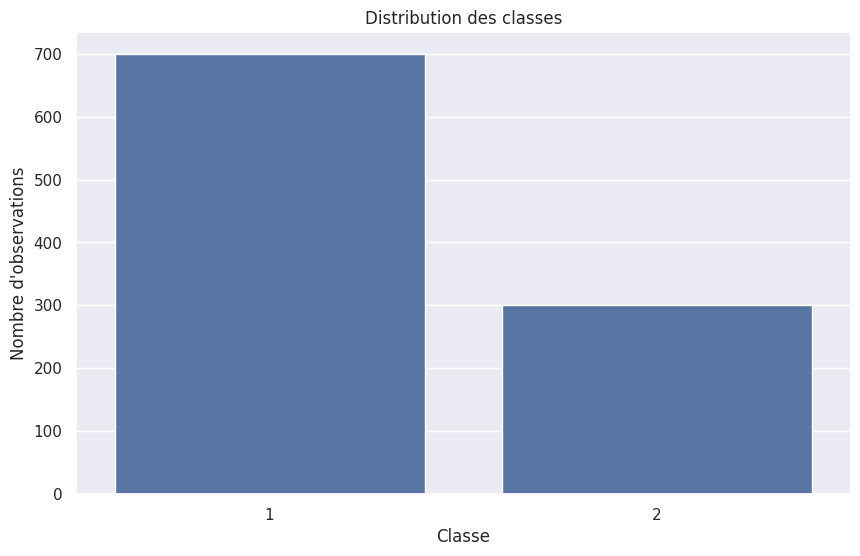

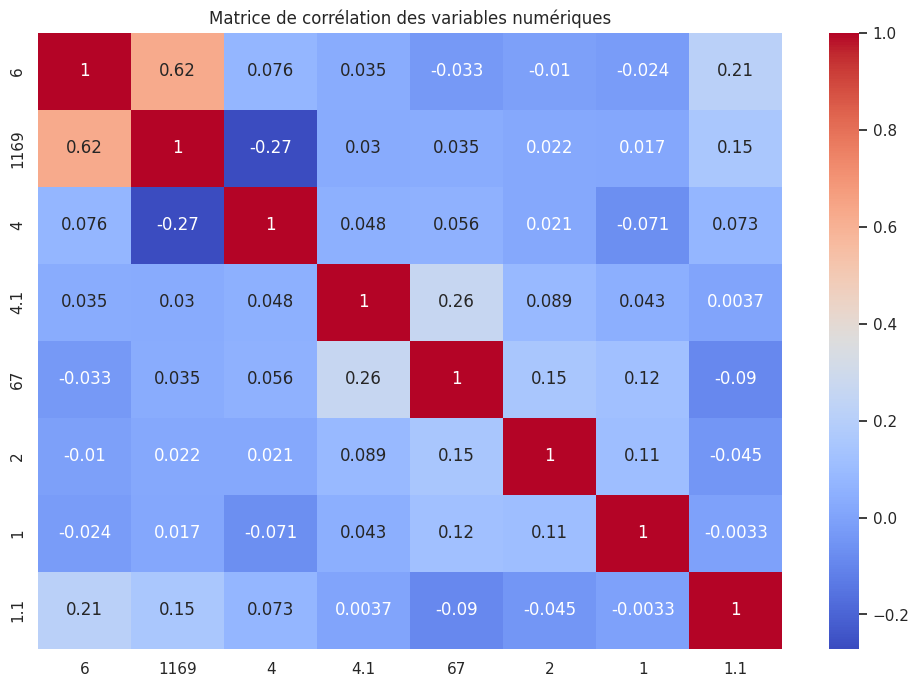

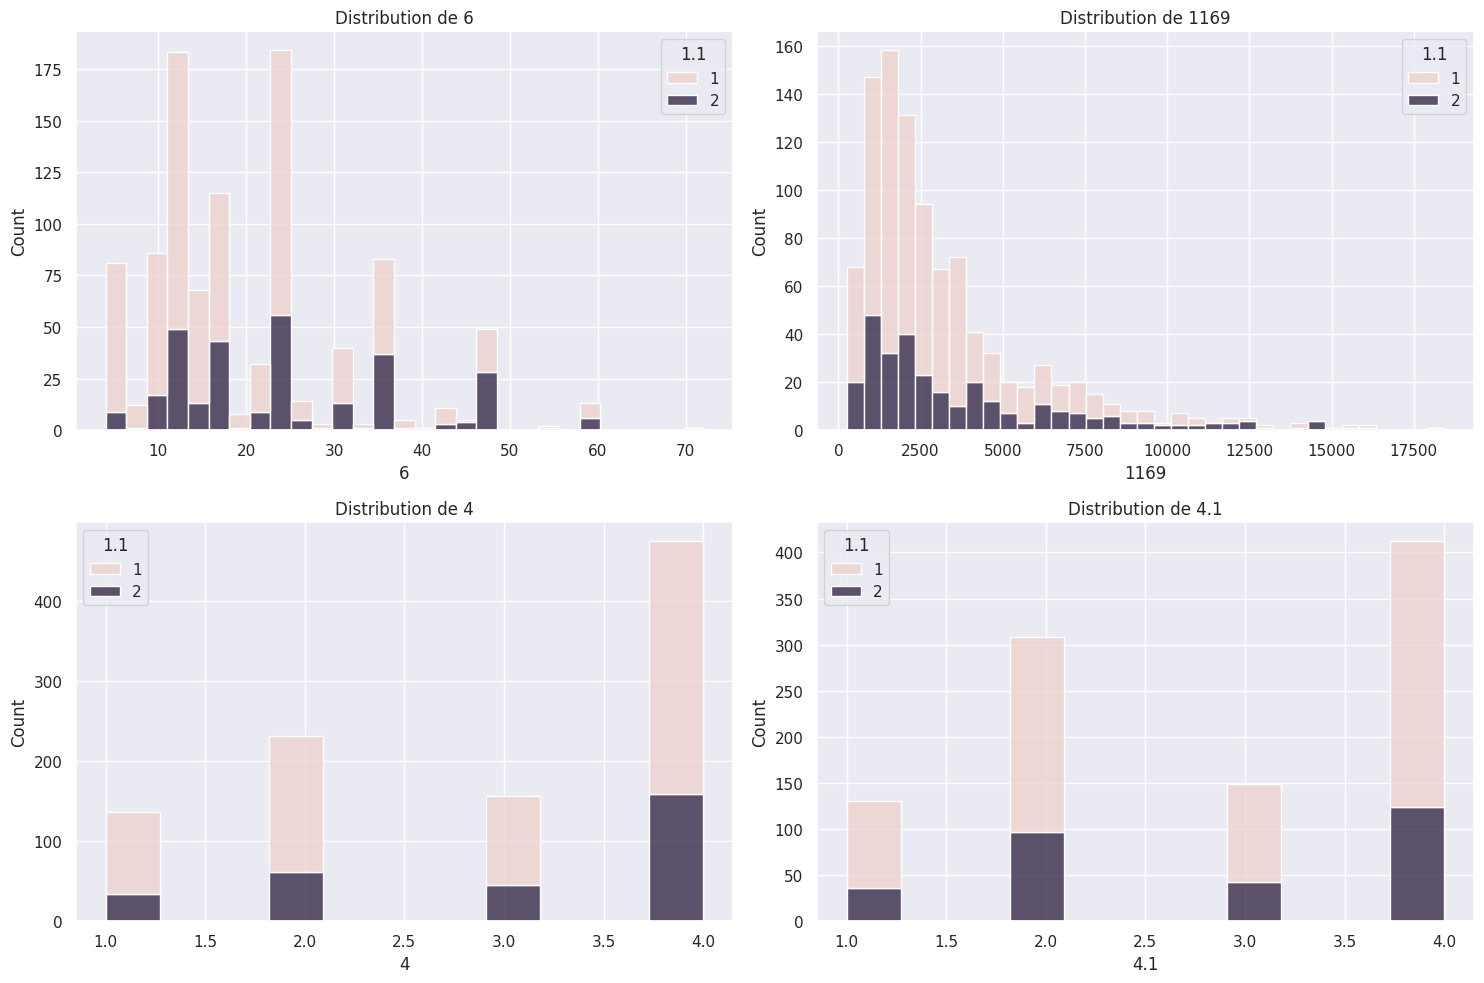

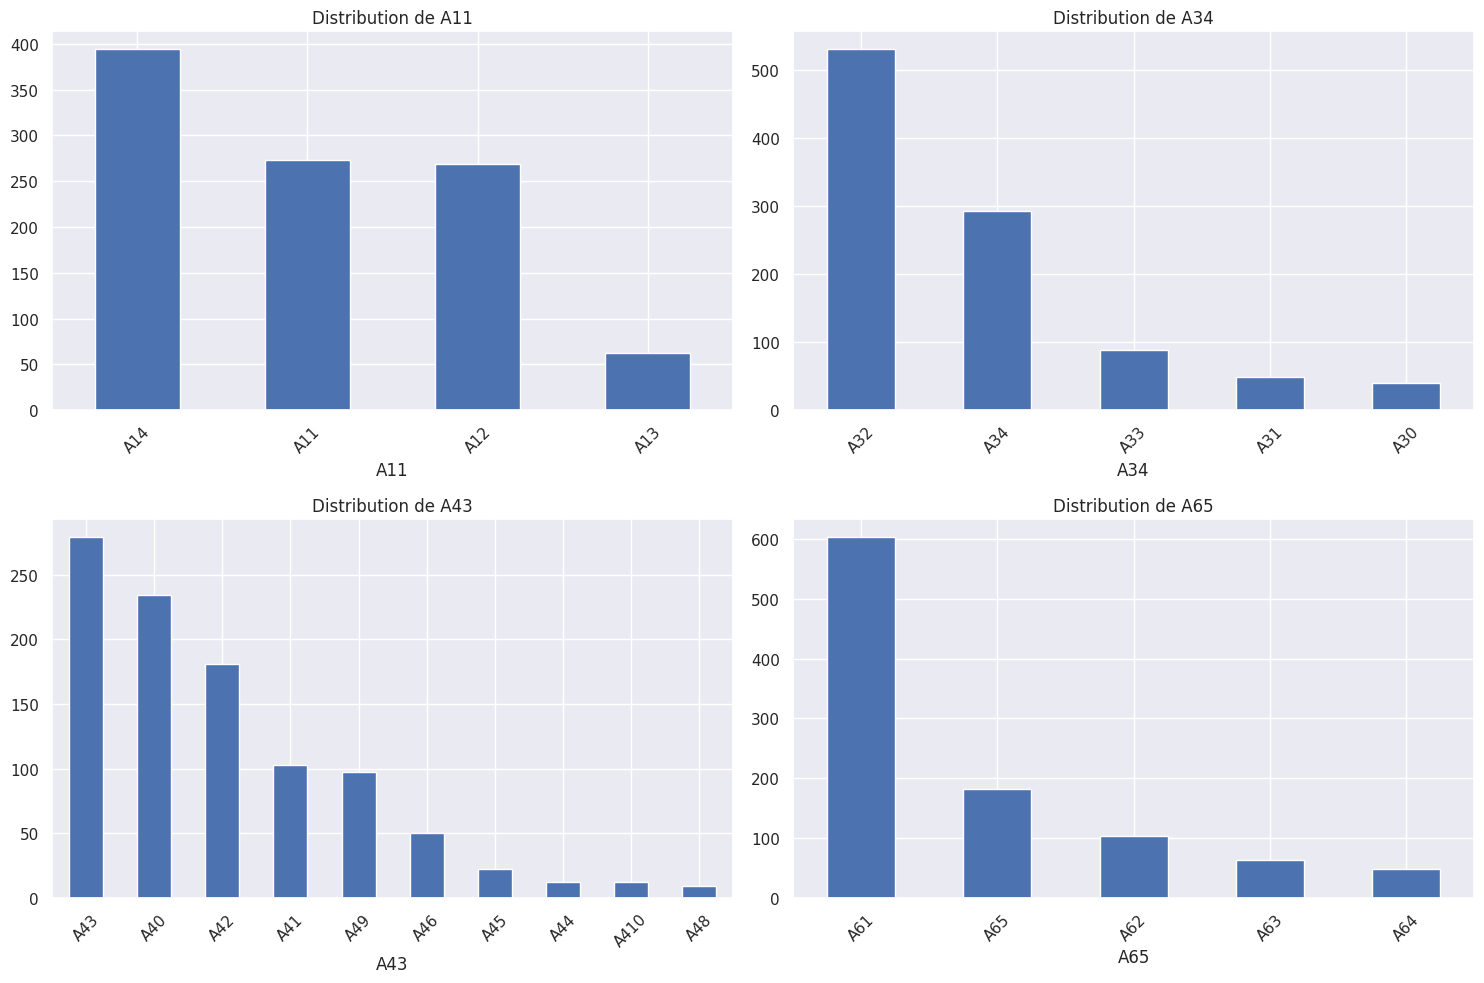

In [3]:
# Statistiques descriptives
print("Statistiques descriptives des variables numériques:")
print(df.describe())

# Distribution des classes
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=df.columns[-1])
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'observations')
plt.show()

# Analyse des variables numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation des variables numériques')
plt.show()

# Distribution des variables numériques principales
num_vars = df.select_dtypes(include=[np.number]).columns[:4]  # Sélection des 4 premières variables numériques
plt.figure(figsize=(15, 10))
for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=var, hue=df.columns[-1], multiple="stack")
    plt.title(f'Distribution de {var}')
plt.tight_layout()
plt.show()

# Analyse des variables catégorielles
cat_cols = df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols[:4], 1):  # Affichage des 4 premières variables catégorielles
    plt.subplot(2, 2, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution de {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Préparation des données

Dimensions des données:
X_train: (1124, 20)
X_test: (200, 20)
y_train: (1124,)
y_test: (200,)


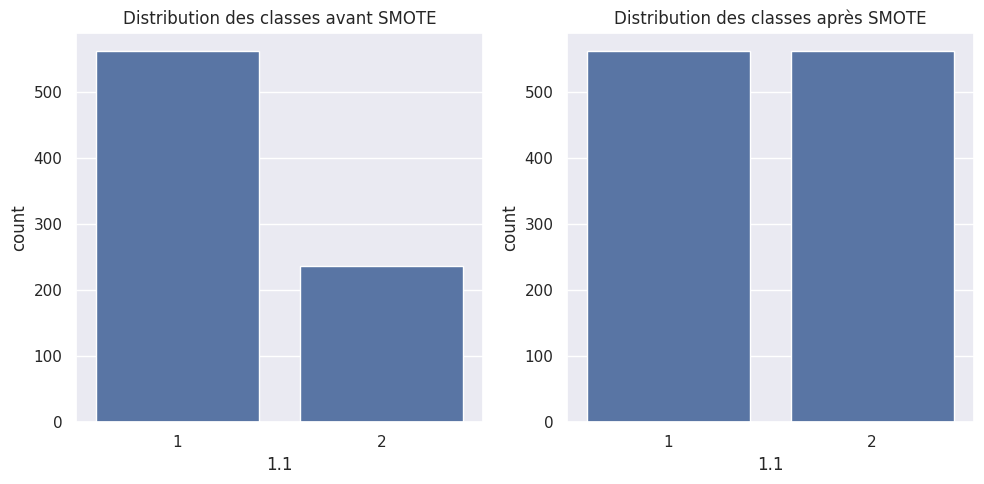

In [4]:
# Séparation features et target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encodage des variables catégorielles
le = LabelEncoder()
for column in X.select_dtypes(include=['object']):
    X[column] = le.fit_transform(X[column])

# Standardisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Application de SMOTE pour gérer le déséquilibre des classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Dimensions des données:")
print(f"X_train: {X_train_balanced.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train_balanced.shape}")
print(f"y_test: {y_test.shape}")

# Vérification de la distribution des classes après SMOTE
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Distribution des classes avant SMOTE')
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_balanced)
plt.title('Distribution des classes après SMOTE')
plt.tight_layout()
plt.show()

### Modélisation et évaluation

In [5]:
# Définition des modèles
models = {
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'SVM Linear': SVC(kernel='linear'),
    'SVM RBF': SVC(kernel='rbf'),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier()
}

# Dictionnaire pour stocker les résultats
results = {}

# Évaluation de chaque modèle
for name, model in models.items():
    print(f"\nÉvaluation du modèle: {name}")

    # Entraînement
    model.fit(X_train_balanced, y_train_balanced)

    # Prédictions
    y_pred = model.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5)

    # Stockage des résultats
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }

    # Affichage des résultats
    print(f"Accuracy: {accuracy:.3f}")
    print(f"CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
    print("\nMatrice de confusion:")
    print(results[name]['confusion_matrix'])
    print("\nRapport de classification:")
    print(results[name]['classification_report'])


Évaluation du modèle: Naive Bayes
Accuracy: 0.650
CV Score: 0.706 (+/- 0.071)

Matrice de confusion:
[[86 51]
 [19 44]]

Rapport de classification:
              precision    recall  f1-score   support

           1       0.82      0.63      0.71       137
           2       0.46      0.70      0.56        63

    accuracy                           0.65       200
   macro avg       0.64      0.66      0.63       200
weighted avg       0.71      0.65      0.66       200


Évaluation du modèle: KNN
Accuracy: 0.660
CV Score: 0.786 (+/- 0.090)

Matrice de confusion:
[[93 44]
 [24 39]]

Rapport de classification:
              precision    recall  f1-score   support

           1       0.79      0.68      0.73       137
           2       0.47      0.62      0.53        63

    accuracy                           0.66       200
   macro avg       0.63      0.65      0.63       200
weighted avg       0.69      0.66      0.67       200


Évaluation du modèle: LDA
Accuracy: 0.695
CV Score: 0.7

### Visualisation des résultats

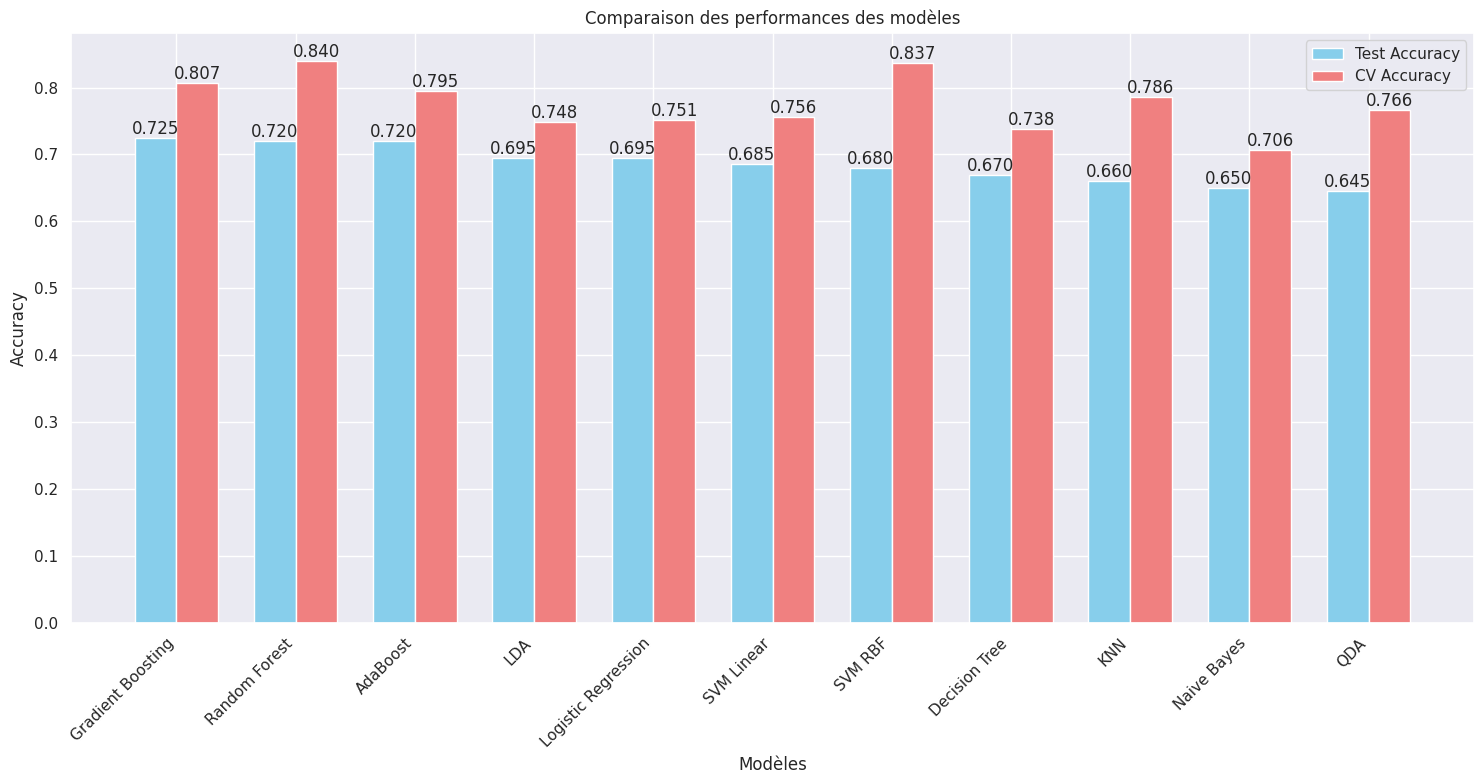

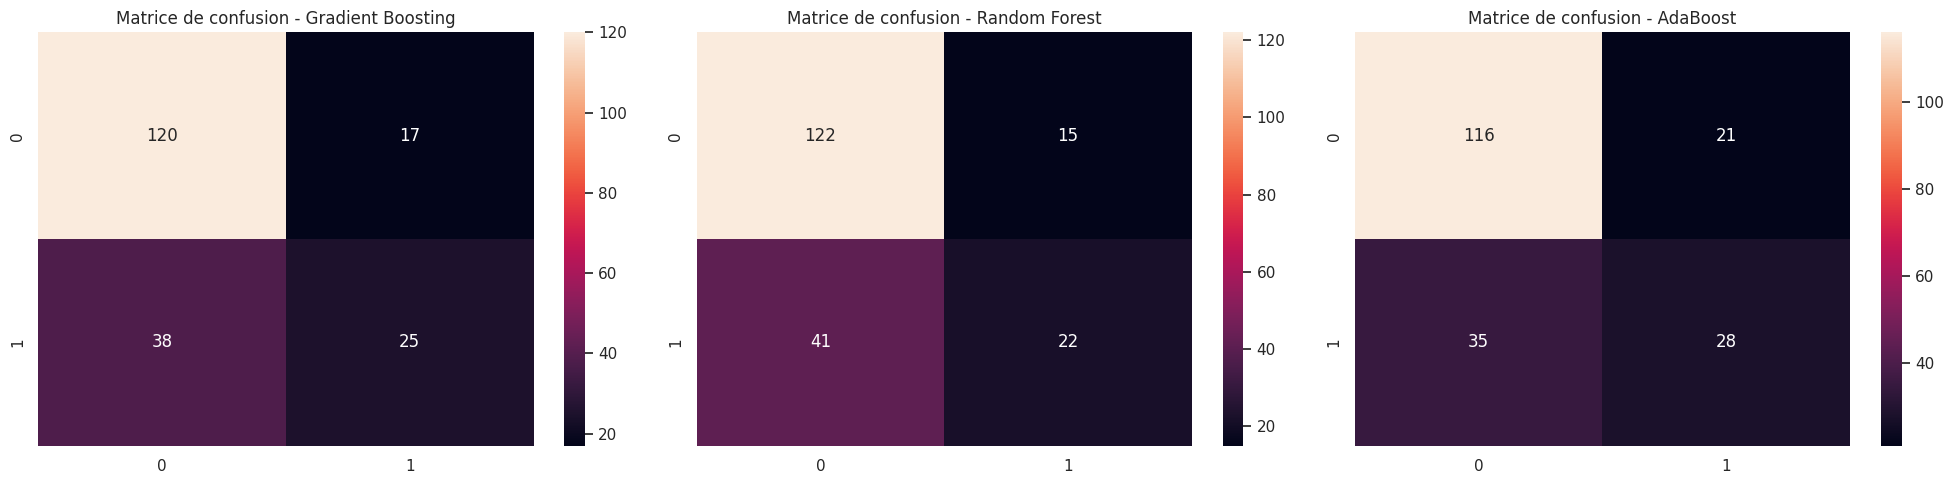

In [6]:
# Création d'un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[model]['accuracy'] for model in results.keys()],
    'CV Mean': [results[model]['cv_mean'] for model in results.keys()],
    'CV Std': [results[model]['cv_std'] for model in results.keys()]
})

# Tri des résultats par accuracy
results_df = results_df.sort_values('Test Accuracy', ascending=False)

# Visualisation des performances des modèles
plt.figure(figsize=(15, 8))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Test Accuracy'], width, label='Test Accuracy', color='skyblue')
plt.bar(x + width/2, results_df['CV Mean'], width, label='CV Accuracy', color='lightcoral')

plt.xlabel('Modèles')
plt.ylabel('Accuracy')
plt.title('Comparaison des performances des modèles')
plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.legend()

# Ajout des valeurs sur les barres
for i in x:
    plt.text(i - width/2, results_df.iloc[i]['Test Accuracy'],
             f"{results_df.iloc[i]['Test Accuracy']:.3f}",
             ha='center', va='bottom')
    plt.text(i + width/2, results_df.iloc[i]['CV Mean'],
             f"{results_df.iloc[i]['CV Mean']:.3f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Visualisation des matrices de confusion pour les meilleurs modèles
best_models = results_df['Model'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, model in enumerate(best_models):
    sns.heatmap(results[model]['confusion_matrix'], annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(f'Matrice de confusion - {model}')
plt.tight_layout()
plt.show()

## Conclusion : Analyse des résultats de la classification des crédits bancaires

### Objet de l'analyse :
Prédire la solvabilité des emprunteurs à partir de données socio-démographiques et financières.

### Description des données :
Le jeu de données "german.csv" contient des informations sur les emprunteurs allemands, incluant des variables numériques (montant du crédit, durée, etc.) et catégorielles (état civil, profession, etc.). La variable cible est la solvabilité (bonne ou mauvaise).

**Variables utilisées**: toutes les variables disponibles dans le jeu de données.  
**Variables supplémentaires** : aucune.

### Analyse proprement dite:
1. **Prétraitement des données**:
   - Encodage des variables catégorielles avec **LabelEncoder**.
   - Standardisation des features numériques avec **StandardScaler**.
   - Gestion du déséquilibre des classes avec **SMOTE** pour sur-échantillonner la classe minoritaire.

2. **Modélisation**:
   - 11 modèles de classification ont été testés : Naive Bayes, KNN, LDA, QDA, SVM (linéaire et RBF), Régression logistique, Arbre de décision, Forêt aléatoire, Gradient Boosting, AdaBoost.
   - Les modèles ont été entraînés sur un ensemble d'entraînement et évalués sur un ensemble de test.
   - Une validation croisée à 5 plis a été effectuée pour estimer la performance généralisée des modèles.

3. **Évaluation** :
   - Les performances sont évaluées en utilisant l'**accuracy**, la **matrice de confusion** et le **rapport de classification**.
   - L'accuracy et la validation croisée ont été calculées pour chaque modèle.
   - Les matrices de confusion des trois meilleurs modèles sont visualisées.

### Commentaires sur les résultats :
Le graphique des performances permet de comparer l'accuracy des modèles sur l'ensemble de test et la moyenne de l'accuracy sur la validation croisée à 5 plis.  
Les matrices de confusion offrent une vue plus détaillée des performances de classification.  
Le meilleur modèle en termes d'accuracy sur le test, tel qu'affiché dans le DataFrame trié, est le **Gradient Boosting**. Toutefois, l'écart entre les différentes méthodes est assez faible.  
Il faut prendre en considération la **standard deviation** dans le **CV score**.

### Justification de la meilleure méthode :

En fonction des données, le **Gradient Boosting** semble être la meilleure méthode car il offre l'accuracy la plus élevée sur l'ensemble de test et une bonne performance lors de la validation croisée. Toutefois, l'écart avec d'autres modèles comme **Random Forest** ou **SVM RBF** est assez réduit.

### Considération de la validation croisée:
L'utilisation de la validation croisée permet d'estimer de façon plus robuste la performance généralisée des modèles. Observer la moyenne de l'accuracy sur la validation croisée est plus pertinent que de se concentrer uniquement sur l'accuracy sur l'ensemble de test, car cela permet d'éviter le surajustement.

### Pourquoi le gradient boosting est plus efficace dans ce cas :
Il permet une amélioration itérative et plus ciblée, ce qui permet de mieux corriger les erreurs et de réduire à la fois le biais et la variance. Sa capacité à minimiser la fonction de perte par gradient le rend très efficace dans ce cas présent.
